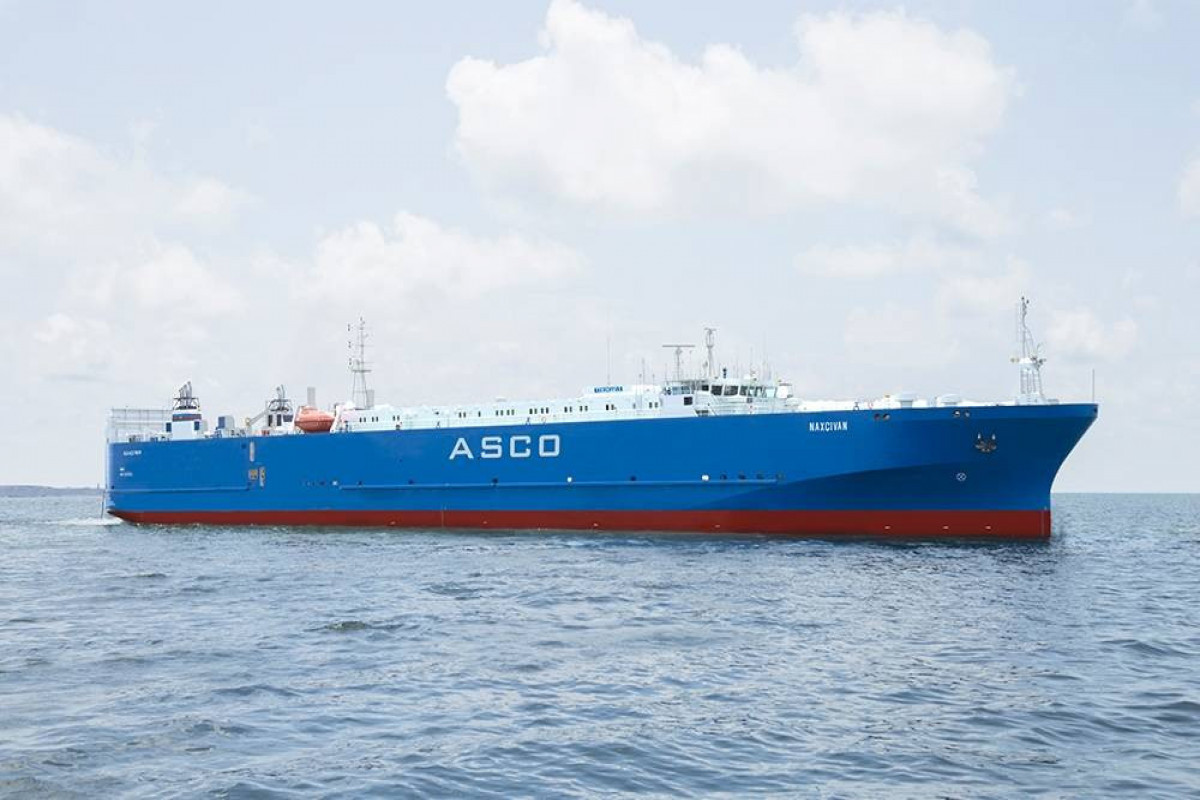

# **Project: Railway Document Data Extraction**

This notebook uses Gemini's vision model to extract structured data from scanned railway shipping documents (transfer manifests, wagon summary tables, and single-wagon SMGS waybills), converting messy scanned paperwork into clean, usable spreadsheets.

In [ ]:
!pip install -q -U google-genai pdf2image
!apt-get update -qq
!apt-get -qq install -y poppler-utils
! pip install -q pypdf

Basically, it installs Python libraries needed later:

- **`google-genai`** - official SDK for calling the Gemini API (sending images, getting structured JSON back)
- **`pdf2image`** - converts PDF pages into image files so they can be sent to the vision model
- **`poppler-utils`** - the underlying system tool `pdf2image` depends on to actually render PDFs
- **`pypdf`** - reads PDF metadata, mainly used here to get the total page count

In [ ]:
import os
from getpass import getpass
from google import genai

os.environ["GEMINI_API_KEY"] = getpass("Enter your Gemini API key: ")
client = genai.Client(api_key = os.environ["GEMINI_API_KEY"])

Enter your Gemini API key: ··········


Prompts you to securely enter your Gemini API key (hidden input, not shown on screen), stores it as an environment variable, then creates the `client` object used in every API call throughout the notebook.

In [ ]:
from google.colab import files

print("Upload PDF(-s): ")
pdf_paths = list(files.upload().keys())
print(f"\nUploaded: {pdf_paths}")

Upload PDF(-s): 


Saving MİNGECHEVİR YUKLENDİ-1-5.pdf to MİNGECHEVİR YUKLENDİ-1-5.pdf

Uploaded: ['MİNGECHEVİR YUKLENDİ-1-5.pdf']


Opens a file picker in Colab so you can upload one or more PDFs, then stores their filenames in `pdf_paths` for use in later cells.

In [ ]:
from pdf2image import convert_from_path
from PIL import Image
import io

def parse_page_spec(spec: str, max_pages: int) -> list[int]:
    # '1, 5, 12-14' -> [1, 5, 12, 13, 14]
    pages = set()
    for part in spec.split(","):
        part = part.strip()
        if "-" in part:
            start, end = part.split("-")
            pages.update(range(int(start), int(end) + 1))
        else:
            pages.add(int(part))
    pages = sorted(pages)
    invalid = [p for p in pages if p < 1 or p > max_pages]
    if invalid:
        raise ValueError(f"Page(s) {invalid} out of range, PDF has {max_pages} page(s)")
    return pages

def pdf_to_images(pdf_path: str, rotation_angle: int = 90, dpi: int = 500, pages_to_extract: list[int] = None):
    # rotation_angle: 0, 90, -90, or 180.
    if pages_to_extract:
        images = convert_from_path(pdf_path, dpi = dpi,
                                    first_page = min(pages_to_extract),
                                    last_page = max(pages_to_extract))
        offset = min(pages_to_extract)
        images = [img for i, img in enumerate(images) if (i + offset) in pages_to_extract]
    else:
        images = convert_from_path(pdf_path, dpi = dpi)
    return [img.rotate(rotation_angle, expand = True) for img in images]

def preview_page(img, max_width = 900):
    ratio = max_width / img.width
    return img.resize((max_width, int(img.height * ratio)))

# Visual check
test_pages = pdf_to_images(pdf_paths[0], rotation_angle = 90)
display(preview_page(test_pages[0]))

- **`parse_page_spec`** - turns a typed string like `"1, 5, 12-14"` into a list of page numbers `[1, 5, 12, 13, 14]`
- **`pdf_to_images`** - converts a PDF (or just selected pages) into rotated images at a given DPI, ready to send to Gemini
- **`preview_page`** - shrinks an image down for easy viewing in the notebook

**Last 2 lines** provide a quick visual check that page 1 is rotated correctly before running the full pipeline.


*Note: cell outputs have been cleared before sharing, since the source documents contain confidential logistics data belonging to ASCO.*

In [ ]:
from pydantic import BaseModel, Field
from typing import Optional, Literal

# AK HESEN STYLE
class WagonRow(BaseModel):
    row_no: int
    wagon_type: Optional[str] = Field(description = "Column 2: wagon type code, e.g. ВГ, БГ")
    wagon_series: Optional[str] = Field(description = "Column 3: series code, e.g. 20, 29, 66")
    wagon_number: str = Field(description = "Column 4: full wagon number, 8 digits")
    container_transport_code: Optional[str] = Field(
        default = None,
        description = "Column 5 (т/р кон): container transport code, usually blank on this document type, leave null if empty"
    )
    container_number: Optional[str] = Field(
        default = None,
        description="Column 6: the container/waybill (накладной) number, an 8-digit number distinct from the wagon number, e.g. 44455566. This column is directly to the right of column 5 and almost always has a value."
    )
    owner_code: Optional[str] = Field(default = None, description = "Column 7 (стр отп): 2-letter code, e.g. UZ")
    origin_station: Optional[str] = Field(default = None, description = "Column 8: Станция отправления")
    destination_station: Optional[str] = Field(default = None, description = "Column 9: Станция назначения")
    cargo_code: Optional[str] = Field(
        default = None,
        description = "Column 10 (стр нзн): a short 2-letter code such as GE, positioned between the destination station column and the cargo name column. This is a real, usually-populated column, do not skip it or return null unless the cell is genuinely empty."
    )
    cargo_name: Optional[str] = Field(default = None, description = "Column 11: Наименование груза")
    net_weight_kg: Optional[int] = Field(default = None, description = "Column 12: Вес гр.кг - net weight, the smaller of the two weight values")
    gross_weight_kg: Optional[int] = Field(default = None, description = "Column 13: Брутто кг - gross weight, the larger of the two weight values")
    loading_date: Optional[str] = Field(default = None, description = "Column 14: Дата погрузки")
    carrier: Optional[str] = Field(default = None, description = "Column 15: Примечание — carrier name, e.g. ADY EXPRESS")

# SHAHDAGH STYLE

class SummaryHeader(BaseModel):
    ferry_name: Optional[str] = Field(default = None, description = "Паром, e.g. Şahdağ")
    origin_port: Optional[str] = Field(default = None, description = "Откуда")
    destination_port: Optional[str] = Field(default = None, description = "Куда")
    voyage_number: Optional[str] = Field(default = None, description = "Рейс №")
    voyage_date: Optional[str] = None
    signatory: Optional[str] = None

class WagonSummaryRow(BaseModel):
    row_no: int
    wagon_number: str = Field(description = "№ Вагонов column")
    waybill_number: str = Field(description = "№ Накладных column")
    container_number: Optional[str] = Field(default = None, description = "№ Контейнеров, handwritten, e.g. '17'")
    station_code: Optional[str] = Field(default = None, description = "Код Стр, e.g. 20, 26, 57")
    origin_station: Optional[str] = Field(default = None, description = "Станция Отправления column")
    destination_station: Optional[str] = Field(default = None, description = "Станция Назначения column")
    cargo_name: Optional[str] = Field(default = None, description = "Наименование Груза column")
    net_weight: Optional[float] = Field(default = None, description = "Вес Нетто column, e.g. 66.983")
    gross_weight: Optional[float] = Field(default = None, description = "Вес Брутто column, e.g. 92.983, must be larger than net_weight")
    ferry_payer: Optional[str] = Field(default = None, description = "За Паром")
    bridge_payer: Optional[str] = Field(default = None, description = "За Мост")

class ManifestHeader(BaseModel):
    manifest_number: Optional[str] = None
    handover_station: Optional[str] = Field(default = None, description = "Станция сдачи")
    receiving_station: Optional[str] = Field(default = None, description = "Станция приема")
    handover_point: Optional[str] = Field(default = None, description = "Передаточная станция")
    train_number: Optional[str] = None
    ferry_name: Optional[str] = None
    total_wagons: Optional[int] = None
    total_gross_weight_tons: Optional[str] = None
    total_net_weight_tons: Optional[str] = None
    total_axles: Optional[int] = None
    handover_date: Optional[str] = None
    handover_time: Optional[str] = None

# Router: classifies the page, fills only the matching branch
class PageExtraction(BaseModel):
    document_type: Literal["transfer_manifest_table", "wagon_summary_table", "other"] = Field(
        description = "Classify this page FIRST, then fill only the matching field(s) below. Leave the rest null/empty."
    )
    manifest_header: Optional[ManifestHeader] = None
    manifest_rows: Optional[list[WagonRow]] = None
    summary_header: Optional[SummaryHeader] = None
    summary_rows: Optional[list[WagonSummaryRow]] = None



# QNQ CODES
class GNGWagonPair(BaseModel):
    gng_code: Optional[str] = Field(
        default=None,
        description="The ГНГ code, found inside box '15 Наименование груза', printed as 'ГНГ' or "
                    "'ГНГ:' followed by a number (e.g. 'ГНГ 99220000'). Extract "
                    "ONLY the digits, not the 'ГНГ' label. Some pages (e.g. a Пересылочная накладная "
                    "'on perevozku porozhnego vagona' form) have no box 15 at all and no ГНГ code - "
                    "if genuinely absent anywhere on the page, return null. Do not invent one."
    )
    wagon_code: str = Field(
        description="The wagon number from box '7 Вагон' (Накладная СМГС forms) or box '1. Вагон' "
                    "(Пересылочная накладная forms). Often handwritten in blue ink over a printed box. "
                    "May be followed by a slash and a 2-digit series code (e.g. '11111111/11') or a "
                    "space and series code (e.g. '22222222 22') - capture the FULL value including "
                    "anything after the slash or space."
    )

A library called **Pydantic** to create a structured blueprint (or template) for organizing data extracted from a railway cargo shipping document. It defines exactly what information needs to be collected and ensures the data matches the right format (like text, numbers, or dates) through three distinct parts:

1. **`WagonRow`** - one row from the 15-column manifest table (wagon number, container number, stations, weights, etc.)
2. **`SummaryHeader`** / **`WagonSummaryRow`** - header info and per-row fields for the ferry summary table style
3. **`ManifestHeader`** - top-level metadata for the 15-column manifest (train number, totals, dates)
4. **`PageExtraction`** - the router: classifies a page as one of the two table types, then fills only the matching fields
5. **`GNGWagonPair`** - the simple two-field schema (ГНГ code + wagon number) used for the single-wagon waybill pages

In [ ]:
import time, random
from google.genai import errors

def call_with_retry(fn, max_retries = 6, base_delay = 8):
    for attempt in range(max_retries):
        try:
            return fn()
        except errors.ClientError as e:
            if "429" in str(e) or "RESOURCE_EXHAUSTED" in str(e):
                delay = base_delay * (2 ** attempt) + random.uniform(0, 3)
                print(f"Rate limited, waiting {delay:.0f}s...")
                time.sleep(delay)
            else:
                raise
    raise RuntimeError("Max retries exceeded")

This cell sets up a safety mechanism to handle **rate limits** when making calls to the Google GenAI API. It ensures that if a request fails because the server is overwhelmed, the program doesn't crash, it pauses and tries again. Here is the how it works:

1. **The `call_with_retry` function** acts as a protective wrapper around any Google GenAI API request we want to make. By default, it allows the program to try running the request up to 6 times before giving up.
2. **Error Catching** code attempts to run the request. If it succeeds, it returns the data immediately. If it encounters an error, it checks if that error is a `429` status code or a `RESOURCE_EXHAUSTED` message, which are standard server codes for "you are sending too many requests right now." If it's a different kind of error (like a typo in your code), it stops and reports it immediately.
3. **Exponential Backoff and Jitter:** If it is a rate limit error, the code calculates a waiting time that doubles with each failed attempt (e.g., 8 seconds, then 16 seconds, then 32 seconds). It also adds a tiny bit of random time (called "jitter") so multiple automated scripts don't all hit the server again at the exact same millisecond.
4. **The Stop Sign** code prints a message showing how long it is waiting, pauses the script, and loops back to try again. If it fails all 6 times, it finally gives up and reports that the maximum number of retries has been exceeded.

In [ ]:
PROMPT = """You will see a scanned page(-s) from a railway shipping document. Classify it as exactly one of:

TYPE "transfer_manifest_table": A wide table titled "Передаточная ведомость" or "Передаточная
поездная ведомость", typewritten in a dot-matrix font, Cyrillic, one row per wagon. It may be
upright or rotated 90 degrees depending on how it was scanned. This table is dense and easy to
misread — read it carefully and methodically using the column-by-column approach described below,
not just a quick left-to-right pass per row.

Columns, left to right, exactly in this order. Column header text is sometimes printed (use it to
confirm alignment) and sometimes missing for a given column — rely on position (1st column after
the axle code, etc.) when a header is absent, not on header text alone:

The table has these columns, left to right, exactly in this order:
1. № п/п — row number
2. вг/кт — wagon type (ВГ, БГ)
3. ад/вк — series code (20, 29, 66...)
4. Номер ваг. — wagon number, 8 digits
5. т/р кон — container transport code, usually BLANK — do not confuse with column 6
6. (unlabeled 8-digit number) — the real container/waybill number, e.g. 50025591, 30078451 —
   this column is almost always populated, immediately right of column 5
7. стр — 2-letter owner code, e.g. UZ
8. Станция отправления — origin station
9. Станция назначения — destination station
10. стр (нзн) — a short 2-letter code such as GE — narrow column between destination station
    and cargo name, easy to visually skip but almost always populated. Look for it specifically.
11. Наименование груза — cargo name
12. Вес гр.кг — net weight (smaller number)
13. Брутто кг — gross weight (larger number)
14. Дата погрузки — loading date
15. Примечание — carrier/remarks

Instructions:
- Read every row exactly as printed. Row numbers usually run from 1 to N or N down to 1.
- Columns 4 and 6 are both 8-digit numbers but are DIFFERENT values (wagon number vs. container
  number) — do not merge or duplicate them, and do not skip column 6 even though it has no header text.
  Plus, Column 6 also can be 6-8 digit numbers, not only 8-digit ones.
- Column 10 is a narrow 2-letter column — actively check for it on every row rather than defaulting
  to null.
- Re-check digit-heavy fields (columns 4, 6, 12, 13) against common dot-matrix misreads: 6/8, 1/7, 3/9, 0/8.
- Column 13 (gross) must be larger than column 12 (net) for a loaded wagon — if reversed, re-check
  which column you read.
- Extract header/summary fields from the top and bottom of the document.
- Do not translate station or cargo names — keep original Cyrillic.
- Every row must appear in the output even if some fields are genuinely blank (use null),
  but do not use null for columns that actually have a printed value.

TYPE "wagon_summary_table": An upright table titled "Передаточная Ведомость" with header info
(Паром/ferry name, Откуда/Куда ports, Рейс №, date) ABOVE the table, and columns:
№ пп, № Вагонов, № Накладных, № Контейнеров (handwritten), Код Стр, Станция Отправления,
Станция Назначения, Наименование Груза, Вес (Нетто, Брутто), Оплата (За Паром, За Мост).
Has a ВСЕГО ВАГОНОВ totals row and a handwritten signatory name at the bottom.
This table's standard layout does NOT include wagon type, series code, owner code, cargo code,
loading date, or carrier name as separate columns — leave those fields null for this type unless
one of them is genuinely present as an extra column on this specific page.

TYPE "other": Anything that isn't one of the two table types above — for example a single-wagon
waybill form (Накладная СМГС, Дорожная ведомость, Пересылочная накладная). This function is now
normally only called on pages already pre-classified as a table type, so "other" should be rare —
but if the page clearly doesn't match either table type, classify it as "other" and leave the
table-specific fields null rather than forcing a bad match.
"""

def extract_page(image: Image.Image) -> PageExtraction:
    buf = io.BytesIO()
    image.save(buf, format = "PNG")
    image_bytes = buf.getvalue()

    from google.genai import types

    def _call():
        return client.models.generate_content(
            model = "gemini-3.5-flash",
            contents = [
                types.Part.from_bytes(data = image_bytes, mime_type = "image/png"),
                PROMPT,
            ],
            config = types.GenerateContentConfig(
                response_mime_type = "application/json",
                response_schema = PageExtraction,
                temperature = 0.0,
                thinking_config = types.ThinkingConfig(thinking_budget = 4096),
            ),
        )

    response = call_with_retry(_call)
    return PageExtraction.model_validate_json(response.text)

This is a function that classifies and extracts data from a scanned page of a railway shipping document, using Google's Gemini model as a vision-language model.

**What it does, step by step:**

1. **Takes an image** of a scanned document page (`image: Image.Image`) and converts it into raw bytes (PNG format) so it can be sent to the AI model.

2. **Sends it to Gemini** (`gemini-3.5-flash`) along with a very detailed instruction prompt (`PROMPT`), asking the model to look at the image and figure out which of three categories it belongs to.

3. **The prompt is essentially a very precise "reading guide"** for the model because it tells it exactly which column is which, warns about columns that look similar (e.g. wagon number vs. container number, both 8-digit), flags common OCR misreads (like confusing 6 and 8, or 1 and 7), and gives a sanity check (gross weight must be bigger than net weight).

4. **Forces structured output**: `response_schema = PageExtraction` and `response_mime_type = "application/json"` mean Gemini doesn't just chat back, it returns data matching a predefined schema (a `PageExtraction` object, presumably a Pydantic model you defined elsewhere).

5. **`temperature = 0.0`** makes the output as deterministic/consistent as possible, it is important for data extraction, where you want the same input to give the same output every time.

6. **`thinking_config`** gives the model a budget of "thinking tokens" to reason internally before producing the final answer, useful for a task this detail-heavy.

7. **`call_with_retry(_call)`** wraps the actual API call so it retries automatically if it fails (rate limits, timeouts, etc.).

8. **Finally**, `PageExtraction.model_validate_json(response.text)` parses the JSON text Gemini returned into a validated Python object, and returns it.

In [ ]:
class PageClassification(BaseModel):
    document_type: Literal[
        "transfer_manifest_table", # 15-column rotated per-wagon table
        "wagon_summary_table", # upright ferry summary table (Паром/Откуда/Куда/Рейс № header)
        "single_wagon_waybill", # СМГС накладная / Дорожная ведомость / Пересылочная накладная
        "other"
    ]

CLASSIFY_PROMPT = """Classify this page as exactly one type:
- "transfer_manifest_table": wide rotated table, one row per wagon, ~15 columns, dot-matrix font
- "wagon_summary_table": upright summary table with Паром/Откуда/Куда/Рейс № header above the table
- "single_wagon_waybill": a single-shipment form (СМГС накладная, Дорожная ведомость, or Пересылочная
  накладная) with numbered boxes, describing ONE wagon
- "other": anything else
Just classify. Do not extract any data."""

def classify_page(image: Image.Image) -> str:
    buf = io.BytesIO()
    image.save(buf, format = "PNG")
    image_bytes = buf.getvalue()

    from google.genai import types

    def _call():
        return client.models.generate_content(
            model = "gemini-3.5-flash",
            contents = [types.Part.from_bytes(data = image_bytes, mime_type = "image/png"), CLASSIFY_PROMPT],
            config = types.GenerateContentConfig(
                response_mime_type = "application/json",
                response_schema = PageClassification,
                temperature = 0.0,
                thinking_config = types.ThinkingConfig(thinking_budget = 0),
            ),
        )

    response = call_with_retry(_call)
    return PageClassification.model_validate_json(response.text).document_type

def classify_pages(pages: list[Image.Image]) -> list[str]:
    return [classify_page(p) for p in pages]

It is a lightweight first-pass classifier, figures out what *type* of page each scan is, without extracting any data yet. **How?:**

1. `classify_page` sends one page image to Gemini with a short prompt listing all possible types.
2. It's told explicitly *not* to extract data, just classify.
3. `thinking_budget = 0` (vs. 4096 in the extractor), no reasoning needed for a simple classification task, so it's faster/cheaper.
4. Returns just the `document_type` string.
5. `classify_pages` runs this over a whole list of page images and returns a list of type labels.

In [ ]:
import pandas as pd
import json
from pypdf import PdfReader

def process_manifest(pdf_path: str, rotation_angle: int = 90, output_dir: str = "manifest_output",
                      page_spec: str = None, page_types: list[str] = None):
    os.makedirs(output_dir, exist_ok = True)
    name = os.path.splitext(os.path.basename(pdf_path))[0]

    total_pages = len(PdfReader(pdf_path).pages)
    pages_to_extract = parse_page_spec(page_spec, total_pages) if page_spec else None

    pages = pdf_to_images(pdf_path, rotation_angle = rotation_angle, pages_to_extract = pages_to_extract)
    print(f"{name}: processing {len(pages)} of {total_pages} page(s)"
          + (f" - pages {pages_to_extract}" if pages_to_extract else " (all)"))

    if page_types is None:
        print("Classifying pages..")
        page_types = classify_pages(pages)

    manifest_header, summary_header = None, None
    manifest_rows, summary_rows = [ ], [ ]

    for i, (page, ptype) in enumerate(zip(pages, page_types)):
        actual_page_num = pages_to_extract[i] if pages_to_extract else i + 1

        if ptype not in ("transfer_manifest_table", "wagon_summary_table"):
            print(f"Page {actual_page_num}: {ptype} - skipped (no extraction call made)")
            continue

        print(f"Page {actual_page_num}: {ptype} is extracting..")
        result = extract_page(page)

        if result.document_type == "transfer_manifest_table":
            if manifest_header is None:
                manifest_header = result.manifest_header
            manifest_rows.extend(result.manifest_rows or [ ])
        elif result.document_type == "wagon_summary_table":
            if summary_header is None:
                summary_header = result.summary_header
            summary_rows.extend(result.summary_rows or [ ])
        else:
            print(f"page {actual_page_num} re-classified as 'other' by extract_page - skipped")

    # moved OUTSIDE the loop, was previously indented one level too deep,
    # causing an early return after the first page

    dfs = { }

    if manifest_rows:
        dfs["transfer_manifest"] = pd.DataFrame([r.model_dump() for r in manifest_rows])
        dfs["transfer_manifest"].to_csv(f"{output_dir}/{name}_transfer_manifest.csv", index = False, encoding = "utf-8-sig")
        if manifest_header:
            with open(f"{output_dir}/{name}_transfer_manifest_header.json", "w", encoding = "utf-8") as f:
                f.write(manifest_header.model_dump_json(indent = 2, exclude_none = True))

    if summary_rows:
        dfs["wagon_summary"] = pd.DataFrame([r.model_dump() for r in summary_rows])
        dfs["wagon_summary"].to_csv(f"{output_dir}/{name}_wagon_summary.csv", index = False, encoding = "utf-8-sig")
        if summary_header:
            with open(f"{output_dir}/{name}_wagon_summary_header.json", "w", encoding = "utf-8") as f:
                f.write(summary_header.model_dump_json(indent = 2, exclude_none = True))

    print(f"\nSaved: {list(dfs.keys())}")
    return dfs

# Run on just the page(s) you type:
dfs = process_manifest(pdf_paths[0], rotation_angle = 90, page_spec = "1")
dfs.get("wagon_summary")

The main pipeline takes a whole PDF, turns pages into images, classifies + extracts each one, and saves the results as CSV/JSON.

**How:**
1. Loads the PDF, optionally restricts to specific pages (`page_spec`), and converts those pages to rotated images.
2. Classifies each page (unless `page_types` is already given).
3. Loops through pages: skips anything that's not a manifest table or summary table; for the rest, calls `extract_page` to pull structured data.
4. Accumulates rows into two buckets (`manifest_rows` and `summary_rows`) plus grabs the header info once from the first matching page.
5. After the loop, converts each bucket into a pandas DataFrame, saves it as a CSV, and saves the header as a separate JSON file.
6. Returns a dict of the DataFrames (`{"transfer_manifest": df, "wagon_summary": df}`).


*Note: cell outputs have been cleared before sharing, since the source documents contain confidential logistics data belonging to ASCO.*

In [ ]:
import io
from PIL import Image

# QNQ SCHEMAS

GNG_WAGON_PROMPT = """This page is a single-wagon railway waybill — either a "Накладная СМГС" form
(numbered boxes 1-29) or a "Пересылочная накладная" form (На перевозку порожнего вагона).

Extract exactly two values from this page:
1. Вагон (wagon) code — box "7 Вагон" on СМГС forms, or box "1. Вагон" on Пересылочная накладная
   forms. Read handwritten/stamped digits carefully. Capture everything in that box, including any
   slash-suffix or space-suffix series code.
2. ГНГ code — box "15 Наименование груза" on СМГС forms only, printed as "ГНГ" or "ГНГ:" followed
   by digits. If this page has no box 15 or no ГНГ label anywhere, return null — do not guess.

Re-check digits against common misreads: 6/8, 1/7, 3/9, 0/8."""

def extract_gng_wagon(image: Image.Image) -> GNGWagonPair:
    buf = io.BytesIO()
    image.save(buf, format="PNG")
    image_bytes = buf.getvalue()

    from google.genai import types

    def _call():
        return client.models.generate_content(
            model = "gemini-3.5-flash",
            contents = [types.Part.from_bytes(data = image_bytes, mime_type = "image/png"), GNG_WAGON_PROMPT],
            config = types.GenerateContentConfig(
                response_mime_type = "application/json",
                response_schema = GNGWagonPair,
                temperature = 0.0,
                thinking_config = types.ThinkingConfig(thinking_budget = 2048),
            ),
        )

    response = call_with_retry(_call)
    return GNGWagonPair.model_validate_json(response.text)

A specialized extractor for single-wagon waybill forms pulls out just two specific codes instead of a whole table.

**How:**
1. Sends the page image to Gemini with a prompt targeting two fields: the **wagon code** (from box 7 or box 1, depending on form type) and the **ГНГ code** (cargo classification code, from box 15, only present on СМГС forms).
2. Tells the model to return `null` for ГНГ if that box doesn't exist, rather than guessing.
3. Same reliability tricks as before: `temperature = 0`, digit-misread warnings (6/8, 1/7, etc.), structured JSON output via `GNGWagonPair` schema.
4. Parses and returns the validated pair.

In [ ]:
def extract_gng_wagon_list(pdf_path: str, rotation_angle: int = 0, page_spec: str = None, page_types: list[str] = None):
    total_pages = len(PdfReader(pdf_path).pages)
    pages_to_extract = parse_page_spec(page_spec, total_pages) if page_spec else None
    pages = pdf_to_images(pdf_path, rotation_angle = rotation_angle, dpi = 500, pages_to_extract = pages_to_extract)

    if page_types is None:
        print("Classifying pages..")
        page_types = classify_pages(pages)

    results = [ ]
    for i, (page, ptype) in enumerate(zip(pages, page_types)):
        actual_page_num = pages_to_extract[i] if pages_to_extract else i + 1

        if ptype != "single_wagon_waybill":
            print(f"Page {actual_page_num}: {ptype} - skipped (no extraction call made)")
            continue

        print(f"Page {actual_page_num}: extracting GNG/wagon..")
        results.append(extract_gng_wagon(page))

    print()
    for i, pair in enumerate(results, start = 1):
        gng = pair.gng_code if pair.gng_code else "-"
        print(f"{i}) QNQ: {gng} -> Wagon: {pair.wagon_code}")

    return results

# Run:
results = extract_gng_wagon_list(pdf_paths[0], rotation_angle = 0)

The cell loads the PDF, converts pages to images (higher DPI = 500, for sharper handwriting reading). Then, classifies pages.

After that, loops through pages, skipping anything that's not a `single_wagon_waybill`. For matching pages, calls `extract_gng_wagon` to pull the wagon + ГНГ code pair.

Lastly, it prints a numbered summary list: `QNQ: <code> -> Wagon: <code>`. And returns the full list of results.


*Note: cell outputs have been cleared before sharing, since the source documents contain confidential logistics data belonging to ASCO.*

In [ ]:
import re
import pandas as pd

def gng_results_to_df(results: list[GNGWagonPair]) -> pd.DataFrame:
    rows = [ ]
    for pair in results:
        wagon_raw = pair.wagon_code or ""
        match = re.match(r"^\s*(\d+)", wagon_raw)
        wagon_number = match.group(1) if match else wagon_raw
        rows.append({
            "wagon_number": wagon_number, # the join key
            "wagon_code_raw": wagon_raw, # full original value
            "gng_code": pair.gng_code,
        })
    return pd.DataFrame(rows)

gng_df = gng_results_to_df(results)
gng_df

,wagon_number,wagon_code_raw,gng_code
0,52913266,52913266,32074085
1,29455953,29455953,32141010
2,29186913,29186913,32141010
3,52565819,52565819,22086011


It converts the raw extraction results into a clean pandas DataFrame, ready to merge with other data.

**How:**
1. For each wagon/ГНГ pair, uses regex to pull out just the **leading digits** of the wagon code (`wagon_number`) (stripping off any slash/space suffix) to create a clean join key.
2. Keeps the original raw value too (`wagon_code_raw`), in case the suffix matters later.
3. Builds a DataFrame with three columns: `wagon_number`, `wagon_code_raw`, `gng_code`.

*Note: cell outputs have been cleared before sharing, since the source documents contain confidential logistics data belonging to ASCO.*

In [ ]:
df = dfs["wagon_summary"]

df["wagon_number"] = df["wagon_number"].astype(str)
gng_df["wagon_number"] = gng_df["wagon_number"].astype(str)

merged_df = df.merge(
    gng_df[["wagon_number", "gng_code"]],
    on = "wagon_number",
    how = "left"
)

merged_df

It joins the ГНГ codes onto the main wagon summary table by matching wagon numbers.

**How:**
1. Converts `wagon_number` to string in both tables (to make sure the join key types match).
2. Left-merges `gng_df` (just the `wagon_number` + `gng_code` columns) into `df` (the wagon summary table) on `wagon_number`.
3. `how = "left"` keeps every row from `df`, wagons with no matching ГНГ code just get `NaN`.

*Note: cell outputs have been cleared before sharing, since the source documents contain confidential logistics data belonging to ASCO.*

In [ ]:
# Finally

***WE WOULD LIKE TO EXPRESS OUR SINCERE GRATITUDES FOR YOUR TIME AND CONSIDERATION***

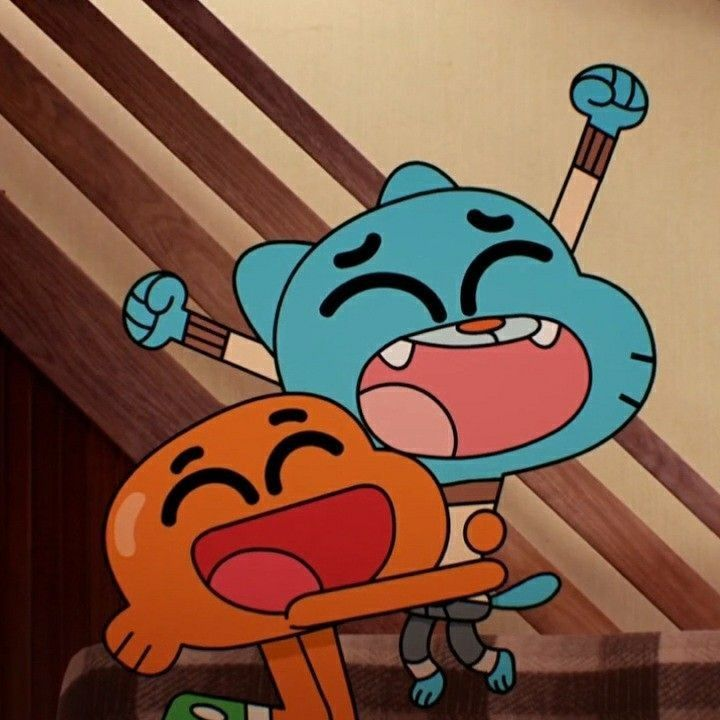